# Continuous-Time Financial Models with Python

**Experiments**
- NVIDIA (`NVDA`) for Geometric Brownian Motion (GBM)
- WTI Crude Oil (`CL=F`) for Ornstein–Uhlenbeck (OU) mean reversion

The two assets are used in separate experiments.

$$
\text{Brownian Motion}
\rightarrow
\text{Itô}
\rightarrow
\text{GBM}
\rightarrow
\text{Calibration}
\rightarrow
\text{OU}
\rightarrow
\text{Equivalent Martingale Measure}
$$

This notebook intentionally stops before Black–Scholes option pricing.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from statsmodels.graphics.tsaplots import plot_acf

TRADING_DAYS = 252
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 1. Brownian motion

For $$0\le s<t,$$

$$
W_t-W_s\sim N(0,t-s),
$$

with independent increments and continuous sample paths. Also,

$$
E[W_t]=0,
\qquad
Var(W_t)=t.
$$

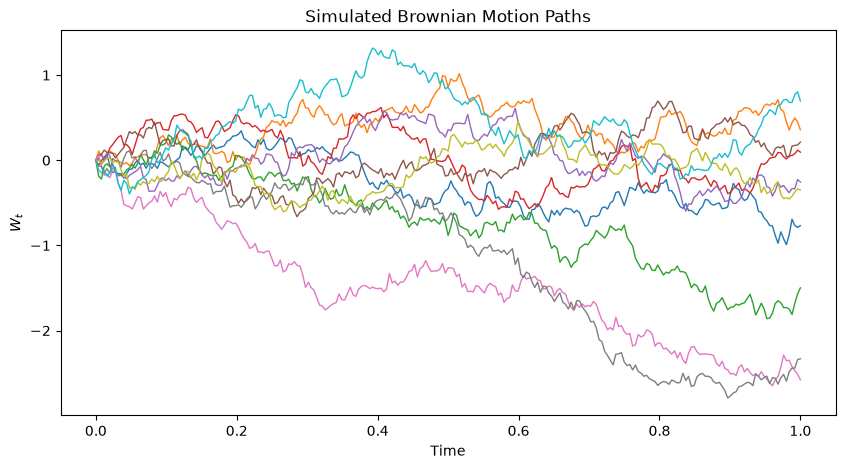

In [2]:
rng = np.random.default_rng(42)

T = 1.0
N = 252
dt = T / N
n_paths = 10

increments = np.sqrt(dt) * rng.standard_normal((n_paths, N))
paths = np.c_[np.zeros(n_paths), np.cumsum(increments, axis=1)]
time = np.linspace(0, T, N + 1)

plt.figure(figsize=(10,5))
for p in paths:
    plt.plot(time, p, linewidth=1)
plt.title("Simulated Brownian Motion Paths")
plt.xlabel("Time")
plt.ylabel(r"$W_t$")
plt.show()

## 2. Itô processes and Itô's lemma

An Itô process has the form

$$
dX_t=u_tdt+v_tdW_t.
$$

If $$g(t,x)$$ is smooth enough,

$$
dg(t,X_t)
=
\left(
g_t+u_tg_x+\frac12v_t^2g_{xx}
\right)dt
+
v_tg_xdW_t.
$$

The extra second-order term is the key difference from ordinary calculus.

## 3. Geometric Brownian Motion

The stock model is

$$
dS_t=\mu S_tdt+\sigma S_tdW_t.
$$

Applying Itô's lemma to

$$
Y_t=\ln S_t,
$$

we obtain

$$
dY_t=
\left(\mu-\frac{\sigma^2}{2}\right)dt+\sigma dW_t.
$$

Hence

$$
S_t=
S_0\exp\left[
\left(\mu-\frac{\sigma^2}{2}\right)t+\sigma W_t
\right]
$$

and

$$
\ln\left(\frac{S_t}{S_0}\right)
\sim
N\left(
\left(\mu-\frac{\sigma^2}{2}\right)t,
\sigma^2t
\right).
$$

## 4. NVIDIA calibration

For daily log returns

$$
X_i=\ln S_{t_i}-\ln S_{t_{i-1}},
$$

with $$Delta t=1/252$$,

$$
X_i\sim
N\left(
\left(\mu-\frac12\sigma^2\right)\Delta t
\sigma^2\Delta t
\right)
$$

Let

$$
m=\frac1n\sum X_i,
\qquad
v=\frac1n\sum(X_i-m)^2.
$$

Then
$$
\hat\sigma^2=\frac{v}{\Delta t},
\qquad
\hat\mu=\frac{m}{\Delta t}+\frac12\hat\sigma^2.
$$

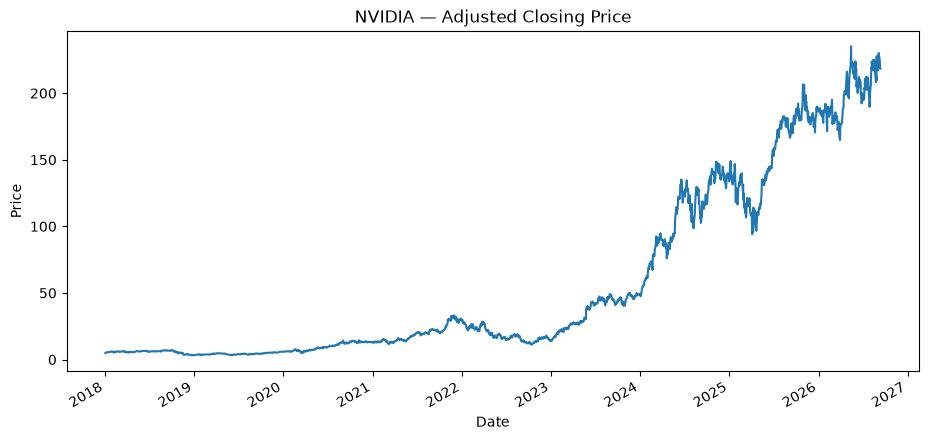

In [3]:
START = "2018-01-01"
END = "2026-09-13"

raw = yf.download("NVDA", start=START, end=END, auto_adjust=True, progress=False)
if raw.empty:
    raise RuntimeError("NVDA data were not downloaded.")

close = raw["Close"]
if isinstance(close, pd.DataFrame):
    close = close.iloc[:, 0]

nvda = close.dropna().rename("NVDA")
nvda_ret = np.log(nvda / nvda.shift(1)).dropna()

ax = nvda.plot(figsize=(11,5), title="NVIDIA — Adjusted Closing Price")
ax.set_ylabel("Price")
plt.show()

In [4]:
dt = 1 / TRADING_DAYS
m = nvda_ret.mean()
v = np.mean((nvda_ret - m)**2)

sigma2_hat = v / dt
sigma_hat = np.sqrt(sigma2_hat)
mu_hat = m / dt + 0.5 * sigma2_hat

pd.Series({
    "mu_hat_annual": mu_hat,
    "sigma_hat_annual": sigma_hat,
}).to_frame("estimate")

,estimate
mu_hat_annual,0.564429
sigma_hat_annual,0.503510


### Independence diagnostic

GBM assumes independent increments. We inspect the autocorrelation of daily log returns:

$$
C(k)=Corr(X_t,X_{t-k}).
$$

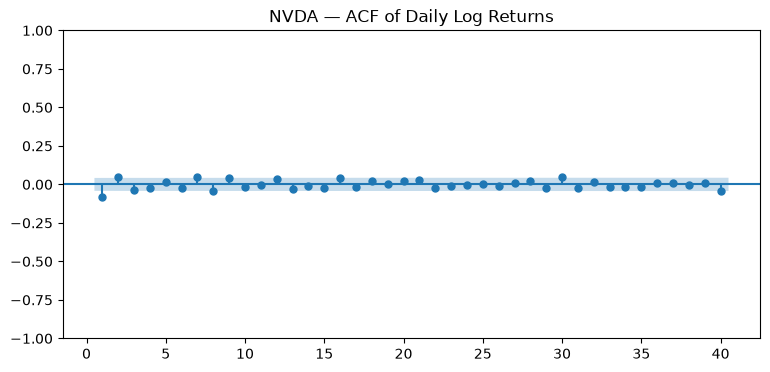

In [5]:
fig, ax = plt.subplots(figsize=(9,4))
plot_acf(nvda_ret, lags=40, zero=False, ax=ax)
ax.set_title("NVDA — ACF of Daily Log Returns")
plt.show()

## 5. GBM simulation

For one step,

$$
S_{t+\Delta t}
=
S_t
\exp\left[
\left(\mu-\frac{\sigma^2}{2}\right)\Delta t
+
\sigma\sqrt{\Delta t}Z
\right],
\qquad Z\sim N(0,1).
$$

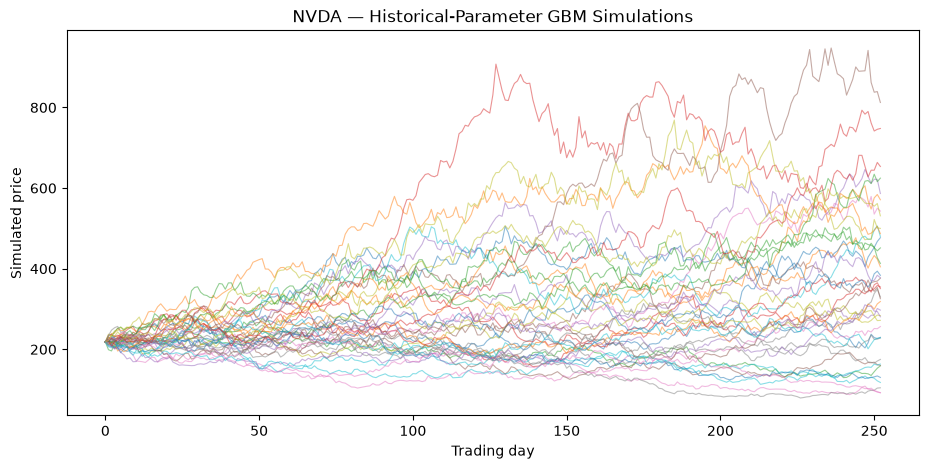

In [6]:
def simulate_gbm(S0, mu, sigma, T=1.0, steps=252, n_paths=2000, seed=42):
    rng = np.random.default_rng(seed)
    dt = T / steps
    z = rng.standard_normal((n_paths, steps))
    inc = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    log_paths = np.c_[np.zeros(n_paths), np.cumsum(inc, axis=1)]
    return S0 * np.exp(log_paths)

S0 = float(nvda.iloc[-1])
gbm_paths = simulate_gbm(S0, mu_hat, sigma_hat)

plt.figure(figsize=(11,5))
for i in range(40):
    plt.plot(gbm_paths[i], alpha=0.5, linewidth=0.8)
plt.title("NVDA — Historical-Parameter GBM Simulations")
plt.xlabel("Trading day")
plt.ylabel("Simulated price")
plt.show()

For GBM,

$$
E[S_t]=S_0e^{\mu t}
$$

and

$$
Var(S_t)=S_0^2e^{2\mu t}\left(e^{\sigma^2t}-1\right).
$$

In [7]:
terminal = gbm_paths[:, -1]
T = 1.0

theoretical_mean = S0*np.exp(mu_hat*T)
theoretical_var = S0**2*np.exp(2*mu_hat*T)*(np.exp(sigma_hat**2*T)-1)

pd.Series({
    "theoretical_terminal_mean": theoretical_mean,
    "simulation_terminal_mean": terminal.mean(),
    "theoretical_terminal_variance": theoretical_var,
    "simulation_terminal_variance": terminal.var(ddof=1),
}).to_frame("value")

,value
theoretical_terminal_mean,383.850576
simulation_terminal_mean,382.197050
theoretical_terminal_variance,"42,516.249386"
simulation_terminal_variance,"42,338.994539"


## 6. Ornstein–Uhlenbeck process

The OU process is

$$
dX_t=\theta(\nu-X_t)dt+\sigma dW_t,
\qquad \theta>0.
$$

Its conditional mean is

$$
E_s[X_t]
=
\nu+(X_s-\nu)e^{-\theta(t-s)}.
$$

As $$t\to\infty,$$

$$
X_t
\Rightarrow
N\left(\nu,\frac{\sigma^2}{2\theta}\right).
$$

This makes OU a natural mean-reversion model for commodities and yields.

## 7. WTI crude oil mean-reversion experiment

The exact discrete-time OU form is

$$
X_i=c+bX_{i-1}+\delta\varepsilon_i,
$$

with

$$
b=e^{-\theta\Delta t},
\qquad
c=\nu(1-b).
$$

Thus,

$$
\hat\theta=-\frac{\ln\hat b}{\Delta t},
\qquad
\hat\nu=\frac{\hat c}{1-\hat b}.
$$

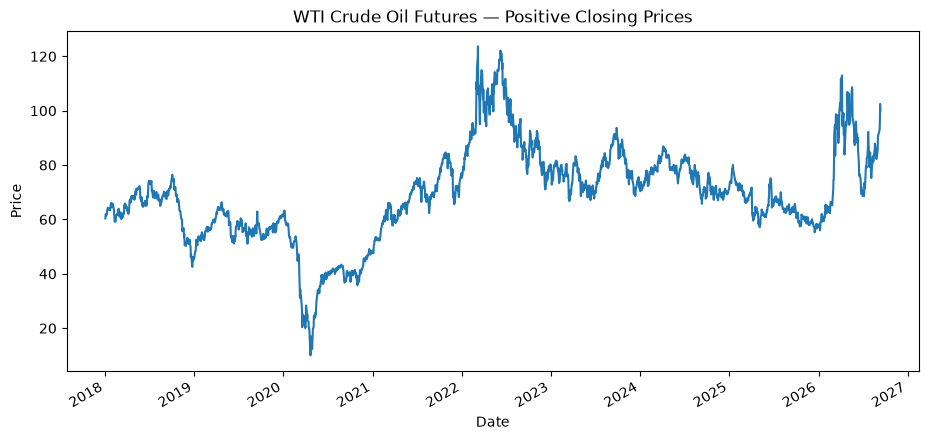

In [8]:
raw_oil = yf.download("CL=F", start=START, end=END, auto_adjust=True, progress=False)
if raw_oil.empty:
    raise RuntimeError("WTI data were not downloaded.")

oil = raw_oil["Close"]
if isinstance(oil, pd.DataFrame):
    oil = oil.iloc[:, 0]

oil = oil.dropna()
oil = oil[oil > 0].rename("WTI")

ax = oil.plot(figsize=(11,5), title="WTI Crude Oil Futures — Positive Closing Prices")
ax.set_ylabel("Price")
plt.show()

In [9]:
x = oil.values.astype(float)
x_prev = x[:-1]
x_next = x[1:]

X = np.column_stack([np.ones_like(x_prev), x_prev])
coef, *_ = np.linalg.lstsq(X, x_next, rcond=None)

c_hat, b_hat = coef
resid = x_next - (c_hat + b_hat*x_prev)
delta2_hat = np.mean(resid**2)

dt_ou = 1 / TRADING_DAYS

if 0 < b_hat < 1:
    theta_hat = -np.log(b_hat) / dt_ou
    nu_hat = c_hat / (1 - b_hat)
    sigma_ou_hat = np.sqrt(
        delta2_hat * 2*theta_hat / (1 - np.exp(-2*theta_hat*dt_ou))
    )
else:
    theta_hat = np.nan
    nu_hat = np.nan
    sigma_ou_hat = np.nan

pd.Series({
    "b_hat": b_hat,
    "theta_hat_annual": theta_hat,
    "nu_hat": nu_hat,
    "sigma_hat_annual": sigma_ou_hat,
}).to_frame("estimate")

,estimate
b_hat,0.994342
theta_hat_annual,1.429986
nu_hat,72.144288
sigma_hat_annual,30.697672


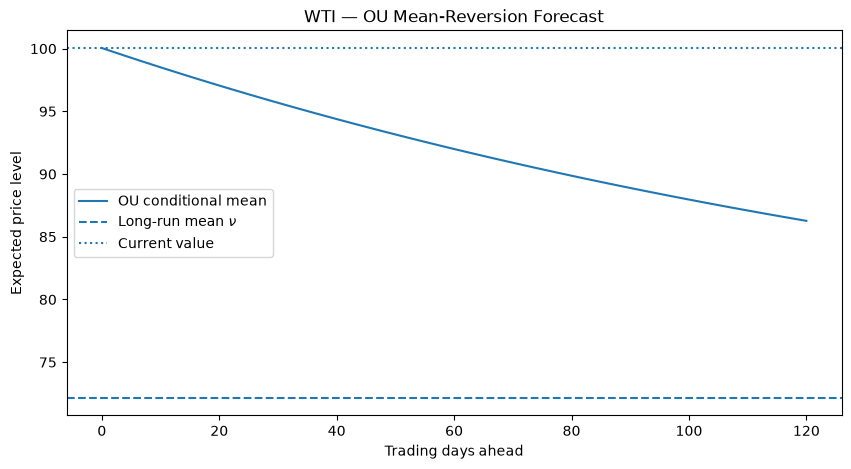

In [10]:
if np.isfinite(theta_hat):
    h = np.arange(121)
    t = h / TRADING_DAYS
    x0 = float(oil.iloc[-1])

    expected_path = nu_hat + (x0 - nu_hat)*np.exp(-theta_hat*t)

    plt.figure(figsize=(10,5))
    plt.plot(h, expected_path, label="OU conditional mean")
    plt.axhline(nu_hat, linestyle="--", label=r"Long-run mean $\nu$")
    plt.axhline(x0, linestyle=":", label="Current value")
    plt.title("WTI — OU Mean-Reversion Forecast")
    plt.xlabel("Trading days ahead")
    plt.ylabel("Expected price level")
    plt.legend()
    plt.show()
else:
    print("OU mapping is not valid because fitted b is outside (0,1).")

## 8. Equivalent martingale measure in continuous time

Under the physical measure $P$,

$$
dS_t=\mu S_tdt+\sigma S_tdW_t^P.
$$

For pricing, we seek an equivalent measure $Q$ under which

$$
\boxed{
dS_t=rS_tdt+\sigma S_tdW_t^Q
}
$$

so the discounted stock price becomes a $Q$-martingale.

This is the continuous-time analogue of replacing physical probability $p$ with risk-neutral probability $q$ in the binomial model.

## 9. Girsanov intuition

Conceptually,

$$
dW_t^Q=dW_t^P+\lambda dt,
$$

where

$$
\lambda=\frac{\mu-r}{\sigma}.
$$

Then

$$
\mu dt+\sigma dW_t^P
=
r dt+\sigma dW_t^Q.
$$

The random diffusion remains; the drift changes from the historical drift $\mu$ to the risk-free drift $r$.

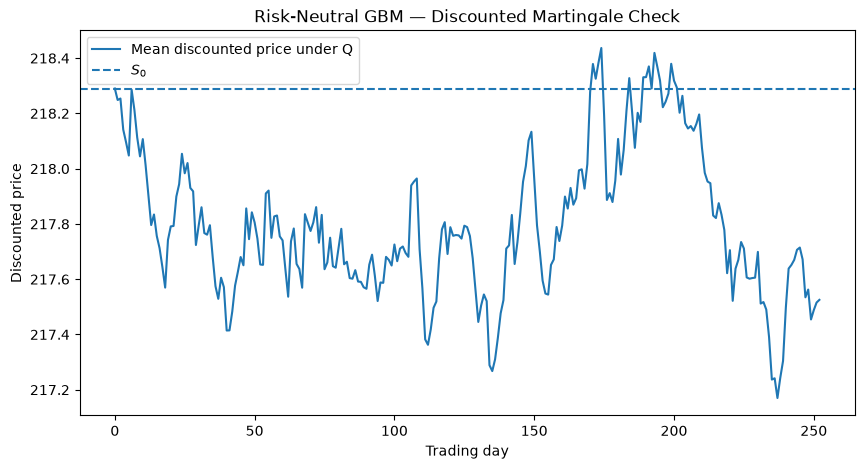

In [11]:
ILLUSTRATIVE_R = 0.03

q_paths = simulate_gbm(
    S0=S0,
    mu=ILLUSTRATIVE_R,
    sigma=sigma_hat,
    T=1.0,
    steps=252,
    n_paths=5000,
    seed=7,
)

discount = np.exp(-ILLUSTRATIVE_R * np.linspace(0, 1, 253))
mean_discounted = (q_paths * discount).mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(mean_discounted, label="Mean discounted price under Q")
plt.axhline(S0, linestyle="--", label=r"$S_0$")
plt.title("Risk-Neutral GBM — Discounted Martingale Check")
plt.xlabel("Trading day")
plt.ylabel("Discounted price")
plt.legend()
plt.show()

## 10. Key takeaways

- Brownian motion supplies the continuous random shocks.
- Itô's lemma is the stochastic version of the chain rule.
- GBM gives positive, lognormally distributed stock prices.
- NVIDIA provides a real-data calibration case for $\mu$ and $\sigma$.
- OU introduces mean reversion and connects naturally to an AR(1)-type model.
- WTI crude oil provides the separate OU experiment.
- Girsanov explains the continuous-time change from the physical measure $P$ to the pricing measure $Q$.
- The notebook intentionally stops before Black–Scholes option pricing.

**Educational quantitative-finance research only — not investment advice.**